In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

def load_trading_data(data_folder: str, round_number: int, days: list[int]) -> dict[str, pd.DataFrame]:
    data = {
        'prices': [],
        'trades': []
    }

    for day in days:
        price_file = os.path.join(data_folder, f'prices_round_{round_number}_day_{day}.csv')
        if os.path.exists(price_file):
            price_df = pd.read_csv(price_file, sep=';')
            if 'timestamp' in price_df.columns:
                price_df = price_df.sort_values('timestamp')
            data['prices'].append(price_df)
        
        trade_file = os.path.join(data_folder, f'trades_round_{round_number}_day_{day}.csv')
        if os.path.exists(trade_file):
            trade_df = pd.read_csv(trade_file, sep=';')
            trade_df['day'] = day
            if 'timestamp' in trade_df.columns:
                trade_df = trade_df.sort_values('timestamp')
            data['trades'].append(trade_df)
    
    result = {}
    for key, dfs in data.items():
        if dfs:
            result[key] = pd.concat(dfs, ignore_index=True)

    return result

def get_product_data(df: pd.DataFrame, product: str) -> pd.DataFrame:
    """
    Filter df for specific product (ex: product = "EMERALDS")
    """
    return df[df['product'] == product]

def get_day_data(df: pd.DataFrame, day: int) -> pd.DataFrame:
    """
    Filter df for per day data
    """
    return df[df['day'] == day]

def get_product_day_data(df: pd.DataFrame, product: str, day: int) -> pd.DataFrame:
    """
    Filter df on both product and day
    """
    return df[df['product'] == product and df['day'] == day]

def get_order_data_per_symbol(df: pd.DataFrame, symbol: str) -> pd.DataFrame:
    """
    Filter order book for orders of the symbol
    """
    return df[df['symbol'] == symbol]

def convert_timestamps(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert timestamps after concatenation
    """
    return df.assign(t=(df['day'] + 2) * 1_000_000 + df['timestamp']).drop(columns=['day', 'timestamp']).sort_values('t')


In [3]:
data = load_trading_data(data_folder='data', round_number=1, days=[0, -1, -2])
price_data = convert_timestamps(data['prices'])
order_data = convert_timestamps(data['trades'])
order_data

,buyer,seller,symbol,currency,price,quantity,t
1503,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9990.0,6,700
1504,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9998.0,2,900
1505,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,9995.0,7,1000
1506,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10011.0,8,2500
1507,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10007.0,7,4000
...,...,...,...,...,...,...,...
738,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10000.0,3,2993400
739,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,13002.0,4,2995000
740,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10000.0,6,2998000
741,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9999.0,5,2998400


In [4]:
ash_data = get_product_data(price_data, "ASH_COATED_OSMIUM")
pepper_data = get_product_data(price_data, "INTARIAN_PEPPER_ROOT")

In [5]:
ash_orders = get_order_data_per_symbol(order_data, "ASH_COATED_OSMIUM")
pepper_orders = get_order_data_per_symbol(order_data, "INTARIAN_PEPPER_ROOT")

C:\Users\Eduard\AppData\Local\Temp\ipykernel_18416\2526764243.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


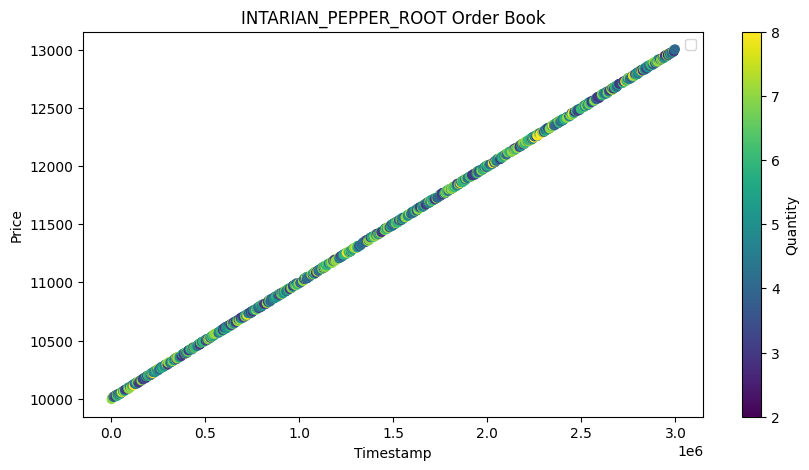

In [6]:
#plotting the data
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.scatter(pepper_orders['t'], pepper_orders['price'], c=pepper_orders['quantity'], cmap='viridis')
plt.colorbar(label='Quantity')
plt.xlabel('Timestamp')
plt.ylabel('Price')
plt.title('INTARIAN_PEPPER_ROOT Order Book')
plt.legend()
plt.show()

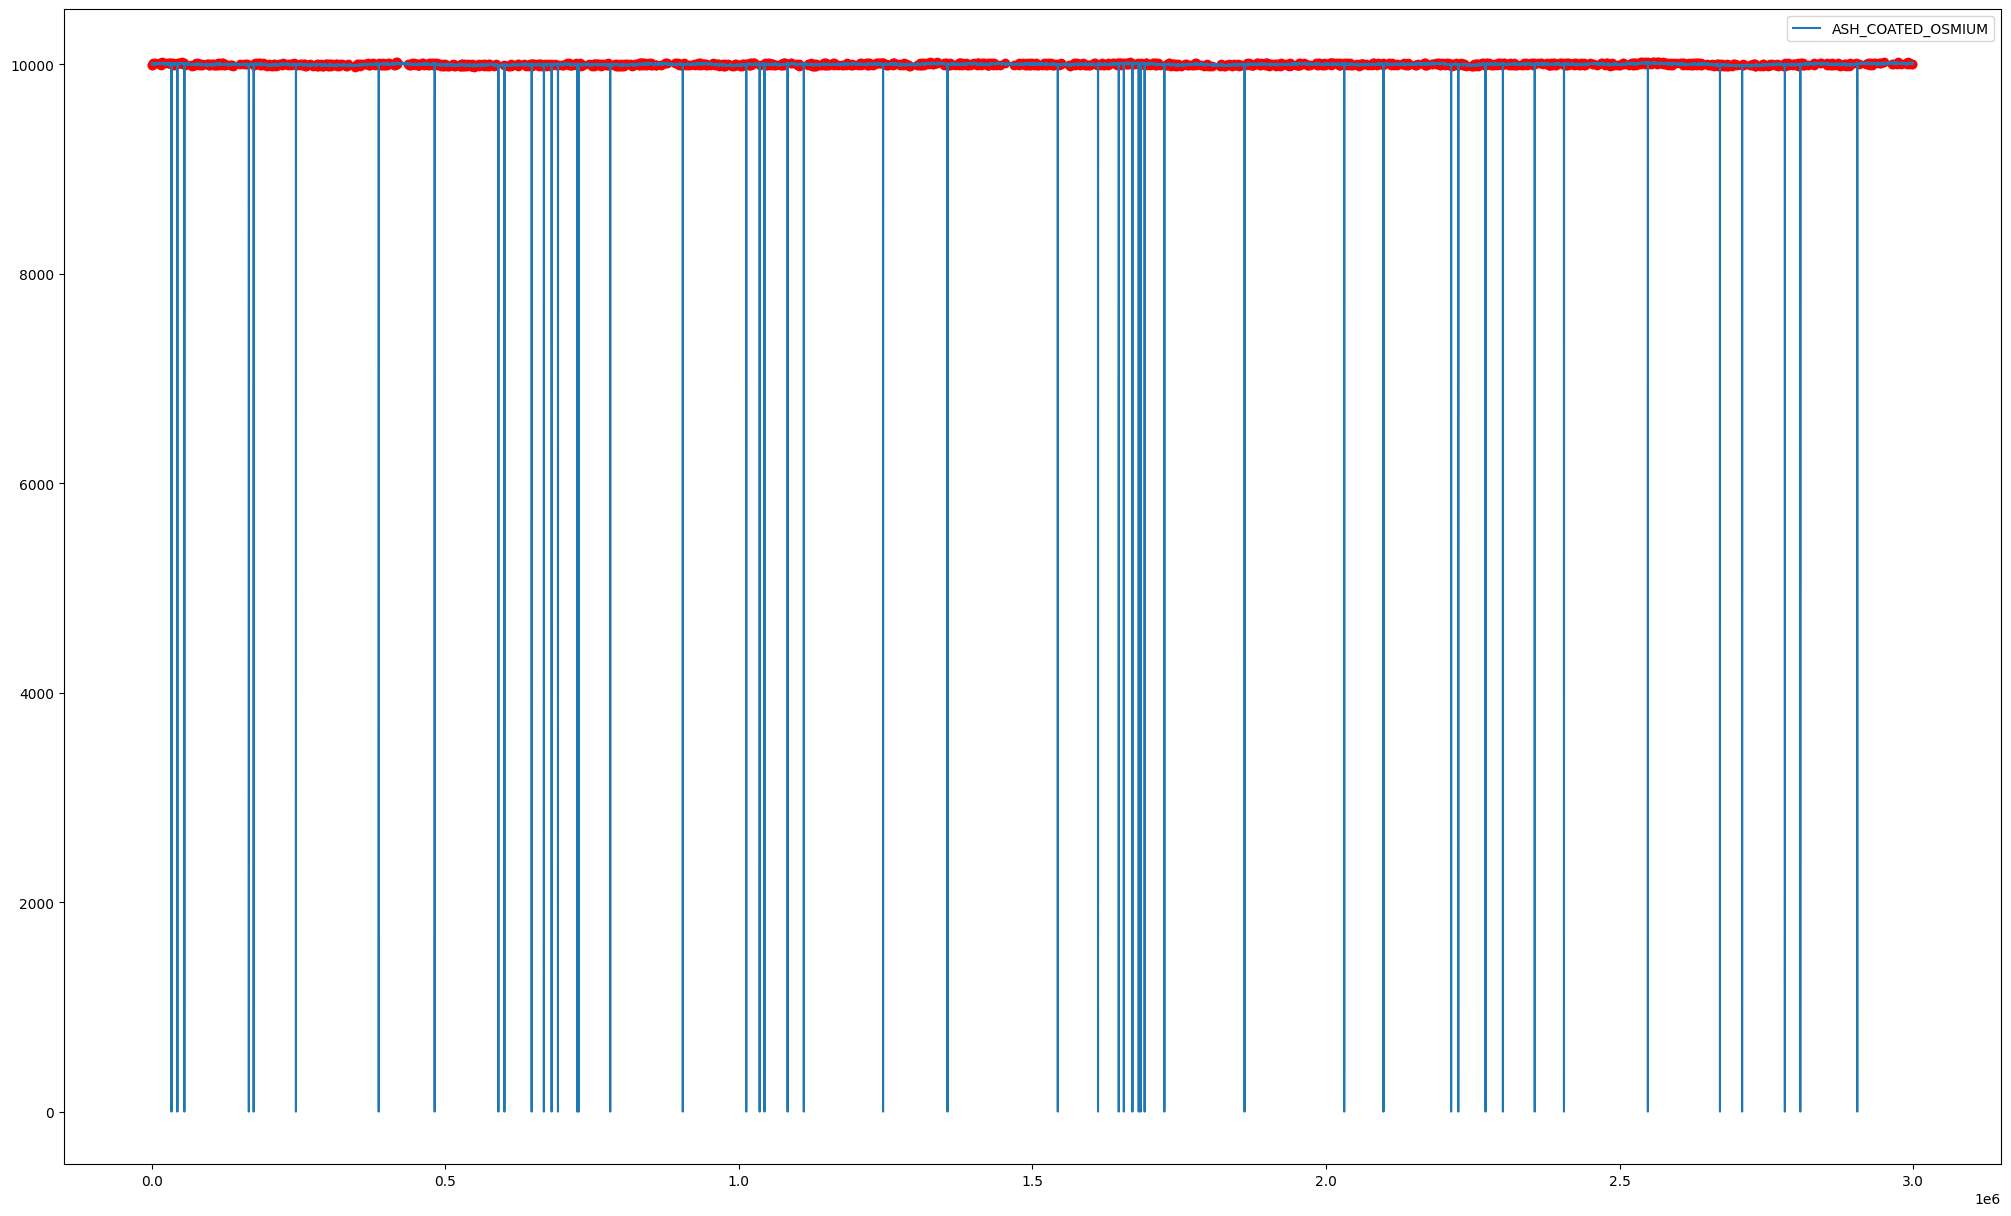

In [7]:
plt.figure(figsize = (25,15))
plt.plot(ash_data['t'], ash_data['mid_price'], label='ASH_COATED_OSMIUM')
plt.scatter(ash_orders['t'], ash_orders['price'], c='r')
plt.legend()
plt.show()